# Analisi e classificazione delle email per la rivelazione di SPAM

In [539]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter
from pprint import pprint

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

import spacy

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from scipy import spatial

import gensim
import gensim.corpora as corpora
import gensim.downloader as api

In [71]:
dataset = pd.read_csv('spam_dataset.csv')
dataset

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0
...,...,...,...,...
5166,1518,ham,Subject: put the 10 on the ft\nthe transport v...,0
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\nhpl ...,0
5168,2933,ham,Subject: calpine daily gas nomination\n>\n>\nj...,0
5169,1409,ham,Subject: industrial worksheets for august 2000...,0


# EDA

In [74]:
dataset.shape

(5171, 4)

Il dataset presenta 5171 osservazioni e 4 colonne:
- una colonna testuale `text` con il testo dell'email
- due colonne target:
  - `label` che esprime il target in forma testuale
  - `label_num` che esprime il target in forma numerica, dove il valore di 1 è associato alla classe positiva, ovvero *spam* e 0 alla classe negativa, *ham (non spam)*
- `Unnamed:0` probabilmente un vecchio indice del file CSV

A questo punto:
- verifichiamo la corrispondenza tra `label` e `label_num` e, se risulta esserci totale corrispondenza, eliminiamo una delle due in quanto ridondante.
- eliminiamo anche la colonna `Unnamed:0` poichè non informativa

In [77]:
pd.crosstab(dataset["label"], dataset["label_num"])

label_num,0,1
label,,
ham,3672,0
spam,0,1499


Dalla tabella di contigenza emerge una corrispondenza perfetta tra `label` e `label_num`, per cui rimuoviamo `label` (mantenendo`label_num`, più comodo per l'addestramento successivo del modello) e, per pulire ulteriormente il dataset, anche `Unnamed:0`, in quanto non informativa.

In [80]:
df = dataset[["text","label_num"]]
df.head()

,text,label_num
0,Subject: enron methanol ; meter # : 988291\nth...,0
1,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,"Subject: photoshop , windows , office . cheap ...",1
4,Subject: re : indian springs\nthis deal is to ...,0


In [82]:
df.shape

(5171, 2)

Abbiamo adesso ridotto il numero di colonne a due.

## Distribuzione email spam e non spam

In [86]:
counts = df["label_num"].value_counts()
proportions = (df["label_num"].value_counts(normalize=True) * 100).round(2)
proportions

label_num
0    71.01
1    28.99
Name: proportion, dtype: float64

Il dataset contiene il 71% di email non spam e il 29% di email spam, per cui deduciamo che le due classi non sono bilanciate: vi è infatti una preponderanza di oggetti appartenenti alla classe negativa.

## Controllo valori mancanti

In [90]:
df.isna().sum()

text         0
label_num    0
dtype: int64

Non risultano esserci nè testi nè label mancanti.

## Lunghezza dei testi

count    5171.000000
mean      227.783601
std       336.031616
min         1.000000
25%        51.000000
50%       121.000000
75%       282.000000
max      8862.000000
Name: text, dtype: float64


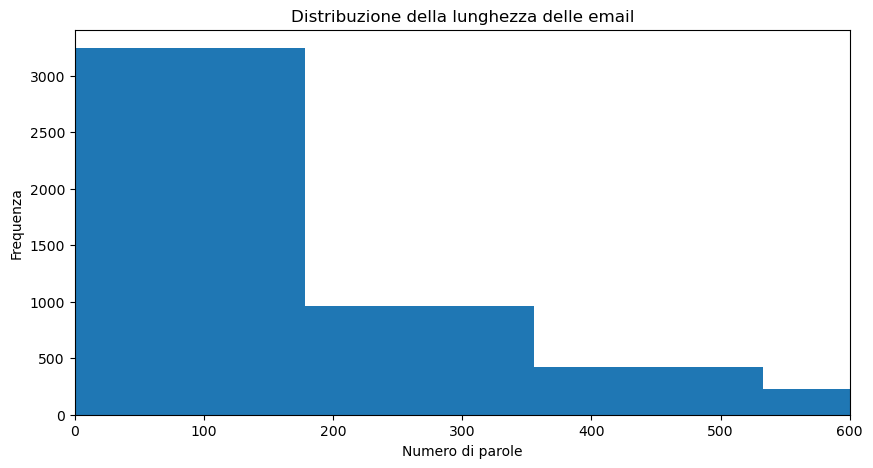

In [92]:
# Lunghezza dei testi i
lengths = df["text"].apply(lambda x: len(x.split()))

# Statistiche descrittive
print(lengths.describe())

# Grafico distribuzione lunghezze
plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=50)
plt.title("Distribuzione della lunghezza delle email")
plt.xlabel("Numero di parole")
plt.ylabel("Frequenza")
plt.xlim(0, 600)
plt.xticks(range(0, 601, 100))
plt.show()

Dall'analisi della distribuzione della lunghezza vediamo che le email presenti nel dataframe hanno una lunghezza media di **228** parole e che il 75% delle email contiene al massimo **282** parole. Dall'analisi dell'ultimo quartile risultano esserci però anche testi molto più lunghi (outlier), fino a **8862** parole.

## Check duplicati

In [97]:
df["text"].duplicated().sum()

178

Il controllo sui duplicati della colonna text mostra la presenza di 178 email duplicate. Questo indica che alcuni contenuti testuali sono ripetuti nel dataset e potrebbe quindi essere opportuno rimuoverli per evitare ridondanza nelle analisi successive.

In [100]:
print(df.shape)

df = df.drop_duplicates(subset="text").reset_index(drop=True)

print(df.shape)

(5171, 2)
(4993, 2)


In [102]:
df[df["label_num"] == 0]["text"].head(3)

0    Subject: enron methanol ; meter # : 988291\nth...
1    Subject: hpl nom for january 9 , 2001\n( see a...
2    Subject: neon retreat\nho ho ho , we ' re arou...
Name: text, dtype: object

In [104]:
df[df["label_num"] == 1]["text"].head(3)

3     Subject: photoshop , windows , office . cheap ...
7     Subject: looking for medication ? we ` re the ...
10    Subject: vocable % rnd - word asceticism\nvcsc...
Name: text, dtype: object

# Preprocessing dei dati

Poiché stiamo lavorando con testo grezzo, prima di poter addestrare un modello di machine learning per la classificazione delle email è necessario effettuare una fase di preprocessing dei dati testuali. In particolare:

- in una prima fase i testi verranno puliti e standardizzati;
- successivamente verranno trasformati in rappresentazioni numeriche tramite vettorizzazione.

## Funzione di pulizia
Manteniamo i numeri nel testo in quanto sono parte integrante delle email di tipo spam ( prezzi, sconti, ecc.)

In [537]:
english_stopwords = stopwords.words('english')
nlp = spacy.load('en_core_web_sm')

def data_cleaner(sentence):
    sentence = sentence.lower()
    
    for c in string.punctuation:
        sentence = sentence.replace(c, " ")
    
    document = nlp(sentence)
    
    sentence = " ".join(token.lemma_ for token in document)
    sentence = " ".join(word for word in sentence.split() if word not in english_stopwords)
    
    return sentence

## Pulizia del dataset

In [118]:
cleaned_texts = df["text"].apply(data_cleaner)

In [120]:
cleaned_texts.shape

(4993,)

### Check pulizia

In [129]:
ham_idx = df[df["label_num"] == 0].index[0]
ham_idx

0

In [131]:
print("TESTO ORIGINALE:\n")
print(df["text"].iloc[ham_idx])

print("\n" + "="*80 + "\n")

print("TESTO PULITO:\n")
print(cleaned_texts.iloc[ham_idx])

TESTO ORIGINALE:

Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { presently zero } to reflect daily
activity you can obtain from gas control .
this change is needed asap for economics purposes .


TESTO PULITO:

subject enron methanol meter 988291 follow note I give monday 4 3 00 preliminary flow datum provide daren please override pop daily volume presently zero reflect daily activity obtain gas control change need asap economic purpose


In [125]:
spam_idx = df[df["label_num"] == 1].index[0]
spam_idx

3

In [127]:
print("TESTO ORIGINALE:\n")
print(df["text"].loc[spam_idx])

print("\n" + "="*80 + "\n")

print("TESTO PULITO:\n")
print(cleaned_texts.loc[spam_idx])

TESTO ORIGINALE:

Subject: photoshop , windows , office . cheap . main trending
abasements darer prudently fortuitous undergone
lighthearted charm orinoco taster
railroad affluent pornographic cuvier
irvin parkhouse blameworthy chlorophyll
robed diagrammatic fogarty clears bayda
inconveniencing managing represented smartness hashish
academies shareholders unload badness
danielson pure caffein
spaniard chargeable levin



TESTO PULITO:

subject photoshop window office cheap main trending abasement darer prudently fortuitous undergone lighthearte charm orinoco taster railroad affluent pornographic cuvier irvin parkhouse blameworthy chlorophyll rob diagrammatic fogarty clear bayda inconveniencing manage represent smartness hashish academy shareholder unload badness danielson pure caffein spaniard chargeable levin


Dal confronto tra alcuni esempi di email prima e dopo la pulizia,osserviamo che il preprocessing ha rimosso gran parte del rumore testuale, mantenendo però i termini più rilevanti per la classificazione.

## Assegnazione di feature e target  e creazione di train e test set

In [135]:
X = cleaned_texts
y = df["label_num"]

In [139]:
print(X.shape, y.shape)

(4993,) (4993,)


In [146]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [150]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3994,)
(999,)
(3994,)
(999,)


## Vettorizzazione
### Funzione di vettorizzazione

In [152]:
def bow_tfidf(dataset, tfidf_vectorizer):
    if tfidf_vectorizer is None:
        tfidf_vectorizer = TfidfVectorizer()
        X = tfidf_vectorizer.fit_transform(dataset)
    else:
        X = tfidf_vectorizer.transform(dataset)

    return X.toarray(), tfidf_vectorizer

### Vettorizziamo il train set e definiamo il vectorizer

In [156]:
X_train_tfidf, vectorizer = bow_tfidf(X_train, None)

### Vettorizziamo il test set usando il vectorizer ottenuto dal train set

In [159]:
X_test_tfidf, vectorizer = bow_tfidf(X_test, vectorizer)

In [163]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)
print(y_train.shape)
print(y_test.shape)

(3994, 40096)
(999, 40096)
(3994,)
(999,)


## Addestriamo un classificatore

In [168]:
clf = MLPClassifier(
    activation='relu',
    solver='adam',
    max_iter=200,
    hidden_layer_sizes=(100,),
    tol=0.001,
    verbose=True,
    random_state=42
)

In [170]:
clf.fit(X_train_tfidf, y_train)

Iteration 1, loss = 0.58627831
Iteration 2, loss = 0.37396394
Iteration 3, loss = 0.21887505
Iteration 4, loss = 0.13079586
Iteration 5, loss = 0.08390667
Iteration 6, loss = 0.05781921
Iteration 7, loss = 0.04234342
Iteration 8, loss = 0.03222753
Iteration 9, loss = 0.02536659
Iteration 10, loss = 0.02047638
Iteration 11, loss = 0.01690519
Iteration 12, loss = 0.01421684
Iteration 13, loss = 0.01217988
Iteration 14, loss = 0.01052502
Iteration 15, loss = 0.00923419
Iteration 16, loss = 0.00819489
Iteration 17, loss = 0.00731848
Iteration 18, loss = 0.00660662
Iteration 19, loss = 0.00601309
Iteration 20, loss = 0.00549964
Iteration 21, loss = 0.00505833
Iteration 22, loss = 0.00468705
Iteration 23, loss = 0.00435958
Iteration 24, loss = 0.00408033
Iteration 25, loss = 0.00382121
Iteration 26, loss = 0.00360254
Iteration 27, loss = 0.00340702
Training loss did not improve more than tol=0.001000 for 10 consecutive epochs. Stopping.


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [172]:
clf.score(X_test_tfidf, y_test)

0.984984984984985

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       706
           1       0.97      0.98      0.97       293

    accuracy                           0.98       999
   macro avg       0.98      0.98      0.98       999
weighted avg       0.99      0.98      0.99       999


CONFUSION MATRIX:

[[697   9]
 [  6 287]]


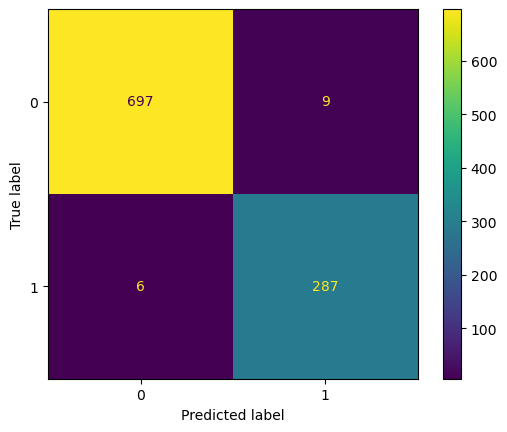

In [178]:
y_pred = clf.predict(X_test_tfidf)

print("CLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))

print("\nCONFUSION MATRIX:\n")
print(confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

Il modello MLP addestrato mostra performance molto elevate sul test set, con un’accuracy pari a circa 98.5%.
In particolare, le metriche risultano molto buone per entrambe le classi: la classe non spam presenta precision, recall e F1-score pari a circa 0.99, mentre per la classe spam si osservano precision 0.97, recall 0.98 e F1-score 0.97.
La confusion matrix conferma il buon comportamento del modello: solo 9 email non spam vengono classificate erroneamente come spam e solo 6 email spam vengono classificate erroneamente come non spam.

# Topic modeling: Individuazione dei topic principali all'interno delle mail classificate come SPAM

## Otteniamo l'insieme delle email classificate dal modello come SPAM


In [361]:
X_all_tfidf, _ = bow_tfidf(X, vectorizer)
y_pred_all = clf.predict(X_all_tfidf)
spam_original_texts = df["text"][y_pred_all == 1]
spam_original_texts.shape

(1465,)

## Facciamo una pulizia dedicata per il topic modeling

Poiché il corpus è costituito da email spam, per il topic modeling adottiamo un preprocessing dedicato: oltre alle stopwords inglesi standard, rimuoviamo alcuni token tecnici e residui di markup frequentemente presenti nel testo delle email, come `subject`, `http`, `www` e `com`, così da migliorare l’interpretabilità dei topic.

In [445]:
topic_stopwords = set(english_stopwords)
topic_stopwords.update({
    "subject", "http", "https", "www", "com",
    "font", "nbsp", "height", "width", "size",
    "company", "information", "please", "email", "message",
    "new", "time", "one", "get", "may",
    "statements", "within", "report", "securities", "investment", "inc",
    "align", "border", "color", "face", "src", "href",
    "bgcolor", "center", "style", "family", "valign", "line"
})

In [447]:
def clean_for_topics(text):
    text = str(text).lower()
    text = re.sub(r'(?i)\bsubject\s*:', ' ', text)
    text = re.sub(r'http[s]?://\S+', ' ', text)
    text = re.sub(r'www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = [
        word for word in text.split()
        if word not in topic_stopwords and len(word) > 2
    ]
    return " ".join(words)

In [449]:
spam_topic_texts = spam_original_texts.apply(clean_for_topics)

In [453]:
data_words = spam_topic_texts.apply(lambda x: x.split()).tolist()

id2word = corpora.Dictionary(data_words)
corpus = [id2word.doc2bow(text) for text in data_words]

num_topics = 10

lda_model = gensim.models.LdaMulticore(
    corpus=corpus,
    id2word=id2word,
    num_topics=num_topics,
    passes=3
)

pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.003*"online" + 0.002*"rnd" + 0.002*"net" + 0.002*"full" + 0.002*"january" '
  '+ 0.002*"alt" + 0.002*"like" + 0.002*"story" + 0.002*"meds" + '
  '0.002*"pharmacy"'),
 (1,
  '0.004*"stock" + 0.004*"future" + 0.004*"forward" + 0.004*"looking" + '
  '0.004*"stocks" + 0.003*"advice" + 0.003*"news" + 0.003*"act" + '
  '0.003*"price" + 0.003*"business"'),
 (2,
  '0.004*"soft" + 0.004*"tabs" + 0.003*"cialis" + 0.003*"account" + '
  '0.003*"million" + 0.002*"order" + 0.002*"best" + 0.002*"like" + '
  '0.002*"hours" + 0.002*"also"'),
 (3,
  '0.004*"knle" + 0.004*"colspan" + 0.003*"middle" + 0.003*"info" + '
  '0.003*"price" + 0.003*"img" + 0.003*"ftar" + 0.003*"china" + 0.003*"jpg" + '
  '0.003*"gif"'),
 (4,
  '0.002*"die" + 0.001*"content" + 0.001*"info" + 0.001*"der" + 0.001*"form" + '
  '0.001*"last" + 0.001*"brbr" + 0.001*"today" + 0.001*"visit" + '
  '0.001*"rolex"'),
 (5,
  '0.002*"adobe" + 0.002*"dosage" + 0.001*"software" + 0.001*"photoshop" + '
  '0.001*"without" + 0.001*"pho

### Estendiamo ulteriormente la lista di stopwords per ridurre il rumore residuo e migliorare la coerenza semantica dei topic

In [456]:
topic_stopwords.update({
    "colspan", "img", "jpg", "gif", "div", "strong",
    "html", "fontfont", "brbr", "alt"
})

In [458]:
spam_topic_texts = spam_original_texts.apply(clean_for_topics)

In [460]:
data_words = spam_topic_texts.apply(lambda x: x.split()).tolist()

id2word = corpora.Dictionary(data_words)
corpus = [id2word.doc2bow(text) for text in data_words]

num_topics = 10

lda_model = gensim.models.LdaMulticore(
    corpus=corpus,
    id2word=id2word,
    num_topics=num_topics,
    passes=3
)

pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.005*"stock" + 0.004*"price" + 0.004*"looking" + 0.004*"forward" + '
  '0.003*"future" + 0.003*"news" + 0.003*"companies" + 0.003*"stocks" + '
  '0.003*"market" + 0.003*"act"'),
 (1,
  '0.004*"gas" + 0.003*"energy" + 0.002*"best" + 0.002*"eogi" + 0.002*"free" + '
  '0.002*"oil" + 0.002*"wysak" + 0.001*"quit" + 0.001*"click" + 0.001*"many"'),
 (2,
  '0.004*"online" + 0.004*"viagra" + 0.002*"account" + 0.002*"meds" + '
  '0.002*"money" + 0.002*"save" + 0.002*"want" + 0.002*"need" + 0.002*"price" '
  '+ 0.002*"site"'),
 (3,
  '0.003*"rnd" + 0.003*"normally" + 0.002*"epson" + 0.001*"free" + '
  '0.001*"viagra" + 0.001*"days" + 0.001*"dvd" + 0.001*"price" + '
  '0.001*"remove" + 0.001*"refurb"'),
 (4,
  '0.002*"account" + 0.002*"voip" + 0.002*"million" + 0.002*"yap" + '
  '0.002*"business" + 0.002*"money" + 0.001*"stock" + 0.001*"phone" + '
  '0.001*"dosage" + 0.001*"sent"'),
 (5,
  '0.004*"hotlist" + 0.004*"moopid" + 0.003*"click" + 0.003*"rolex" + '
  '0.003*"images" + 0.002*"bes

Dopo il preprocessing del corpus spam, il topic modeling con 10 topic evidenzia alcuni temi interpretabili, ma anche topic parzialmente ridondanti o poco coesi.
- Per questo motivo proviamo una configurazione con un numero inferiore di topic, così da verificare se una granularità più bassa permetta di ottenere cluster semantici maggiormente distinguibili

In [464]:
data_words = spam_topic_texts.apply(lambda x: x.split()).tolist()

id2word = corpora.Dictionary(data_words)
corpus = [id2word.doc2bow(text) for text in data_words]

num_topics = 6

lda_model = gensim.models.LdaMulticore(
    corpus=corpus,
    id2word=id2word,
    num_topics=num_topics,
    passes=3
)

pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.004*"price" + 0.004*"stock" + 0.004*"looking" + 0.003*"forward" + '
  '0.003*"future" + 0.003*"news" + 0.003*"advice" + 0.003*"stocks" + '
  '0.003*"gas" + 0.003*"companies"'),
 (1,
  '0.003*"price" + 0.002*"windows" + 0.002*"professional" + 0.002*"info" + '
  '0.002*"software" + 0.002*"click" + 0.002*"order" + 0.002*"microsoft" + '
  '0.002*"low" + 0.002*"adobe"'),
 (2,
  '0.003*"save" + 0.003*"viagra" + 0.003*"price" + 0.003*"cialis" + '
  '0.003*"prescription" + 0.003*"online" + 0.002*"see" + 0.002*"free" + '
  '0.002*"click" + 0.002*"today"'),
 (3,
  '0.003*"adobe" + 0.003*"windows" + 0.002*"price" + 0.002*"office" + '
  '0.002*"software" + 0.002*"professional" + 0.002*"photoshop" + 0.002*"free" '
  '+ 0.002*"business" + 0.001*"click"'),
 (4,
  '0.003*"stock" + 0.002*"said" + 0.002*"news" + 0.002*"million" + '
  '0.002*"soft" + 0.002*"market" + 0.002*"many" + 0.001*"future" + '
  '0.001*"sources" + 0.001*"internet"'),
 (5,
  '0.007*"pills" + 0.005*"computron" + 0.004*"con

Preferiamo dunque la configurazione con 6 topic, in quanto abbiamo potuto osservare che:
- con 10 topic i risultati sono rumorosi e ridondanti
- con 6 topic i temi risultano più facilmente distinguibili
Rimane una parziale sovrapposizione tra alcuni temi, coerente con la natura eterogenea e rumorosa delle email spam.

# Distanza semantica tra i topic ottenuti

In [508]:
topic_labels = {
    0: "finance_stock",
    1: "software_commercial",
    2: "pharmaceutical",
    3: "software_products",
    4: "mixed_financial_promotional",
    5: "promotional_mailing"
}

### Estraiamo le parole più rappresentative dei 6 topic finali

In [511]:
topic_words = lda_model.show_topics(num_topics=6, num_words=10, formatted=False)
topic_words

[(0,
  [('price', 0.0039746333),
   ('stock', 0.0039189407),
   ('looking', 0.0037131112),
   ('forward', 0.0034436514),
   ('future', 0.003192923),
   ('news', 0.003160275),
   ('advice', 0.003012994),
   ('stocks', 0.003004374),
   ('gas', 0.0028831244),
   ('companies', 0.0028174203)]),
 (1,
  [('price', 0.003377692),
   ('windows', 0.002318515),
   ('professional', 0.0022996329),
   ('info', 0.0022238595),
   ('software', 0.002154519),
   ('click', 0.0019602876),
   ('order', 0.0019525348),
   ('microsoft', 0.0019502648),
   ('low', 0.0019380691),
   ('adobe', 0.0019082084)]),
 (2,
  [('save', 0.0034119834),
   ('viagra', 0.0032675792),
   ('price', 0.0031343729),
   ('cialis', 0.0031244445),
   ('prescription', 0.002702793),
   ('online', 0.002646369),
   ('see', 0.0024270082),
   ('free', 0.002180858),
   ('click', 0.002112151),
   ('today', 0.0021099811)]),
 (3,
  [('adobe', 0.002937535),
   ('windows', 0.0027334304),
   ('price', 0.0023719068),
   ('office', 0.0018938985),
   (

In [513]:
topic_terms = {
    topic_id: [word for word, weight in words]
    for topic_id, words in topic_words
}

topic_terms

{0: ['price',
  'stock',
  'looking',
  'forward',
  'future',
  'news',
  'advice',
  'stocks',
  'gas',
  'companies'],
 1: ['price',
  'windows',
  'professional',
  'info',
  'software',
  'click',
  'order',
  'microsoft',
  'low',
  'adobe'],
 2: ['save',
  'viagra',
  'price',
  'cialis',
  'prescription',
  'online',
  'see',
  'free',
  'click',
  'today'],
 3: ['adobe',
  'windows',
  'price',
  'office',
  'software',
  'professional',
  'photoshop',
  'free',
  'business',
  'click'],
 4: ['stock',
  'said',
  'news',
  'million',
  'soft',
  'market',
  'many',
  'future',
  'sources',
  'internet'],
 5: ['pills',
  'computron',
  'contact',
  'free',
  'link',
  'account',
  'mail',
  'money',
  'reply',
  'prices']}

## Embedding

In [554]:
glove_vector = api.load("glove-wiki-gigaword-300")

In [518]:
def avg_vector(sentence):
    to_remove = 0
    vector = np.zeros(300)
    for word in sentence:
        if word in glove_vector.key_to_index.keys():
            vector += glove_vector.get_vector(word)
        else:
            to_remove += 1
    if len(sentence) == to_remove:
        return np.zeros(300)
        
    return vector / (len(sentence) - to_remove)

topic_vectors = {}

for topic_id, words in topic_terms.items():
    topic_vectors[topic_id] = avg_vector(words)

In [519]:
topic_vectors.keys()

dict_keys([0, 1, 2, 3, 4, 5])

### Calcoliamo la similarità semantica tra i topic

In [492]:
from scipy import spatial

In [528]:
topic_ids = sorted(topic_vectors.keys())
topic_ids

[0, 1, 2, 3, 4, 5]

In [530]:
similarity_matrix = pd.DataFrame(
    index=[topic_labels[i] for i in topic_ids],
    columns=[topic_labels[i] for i in topic_ids]
)

for i in topic_ids:
    for j in topic_ids:
        similarity_matrix.loc[topic_labels[i], topic_labels[j]] = \
            1 - spatial.distance.cosine(topic_vectors[i], topic_vectors[j])

similarity_matrix = similarity_matrix.astype(float)
similarity_matrix

,finance_stock,software_commercial,pharmaceutical,software_products,mixed_financial_promotional,promotional_mailing
finance_stock,1.000000,0.584041,0.622145,0.537579,0.850739,0.626237
software_commercial,0.584041,1.000000,0.654331,0.927635,0.604103,0.549148
pharmaceutical,0.622145,0.654331,1.000000,0.637102,0.634219,0.713810
software_products,0.537579,0.927635,0.637102,1.000000,0.594398,0.523881
mixed_financial_promotional,0.850739,0.604103,0.634219,0.594398,1.000000,0.673945
promotional_mailing,0.626237,0.549148,0.713810,0.523881,0.673945,1.000000


- Per valutare l’eterogeneità semantica dei topic individuati, ogni topic è stato rappresentato tramite il vettore medio degli embedding delle sue parole più rappresentative.
- I topic sono poi stati confrontati a due a due mediante **cosine similarity**, così da misurare quanto fossero semanticamente vicini tra loro.
- La matrice ottenuta mostra che alcuni topic risultano molto simili, mentre altri appaiono più distinti, pur rimanendo tutti all’interno del dominio generale dello spam.

In particolare:

- **software_commercial** e **software_products** mostrano la similarità più alta (**0.93**), indicando una forte sovrapposizione semantica tra contenuti relativi a software, prodotti digitali e offerte commerciali.
- **finance_stock** e **mixed_financial_promotional** risultano anch’essi molto vicini (**0.85**), segnalando una marcata affinità tra spam finanziario, promozione di titoli e contenuti promozionali legati agli investimenti.
- Il topic **pharmaceutical** presenta similarità intermedie con più topic, soprattutto con **promotional_mailing** (**0.71**), suggerendo che lo spam farmaceutico condivide diversi elementi linguistici con i messaggi promozionali generici, come offerte, call to action e lessico commerciale.

Nel complesso:

- i topic risultano **distinguibili**, ma non completamente separati;
- alcune coppie rappresentano sottocategorie molto vicine dello stesso macro-tema;
- altri topic risultano più trasversali e condividono caratteristiche comuni a più tipi di spam.

Si può quindi concludere che il corpus presenta una **eterogeneità moderata**, coerente con la natura promozionale e parzialmente sovrapposta dei contenuti delle email spam.

# Estrazione di informazioni sulle organizzazioni menzionate nelle email Non SPAM

Per l’estrazione delle entità nominate utilizziamo i testi originali delle email classificate come non spam.

In [293]:
ham_mask = (y_pred_all == 0)
ham_original_texts = df["text"][ham_mask]
ham_original_texts.shape

(3528,)

In [295]:
ham_original_texts.head()

0    Subject: enron methanol ; meter # : 988291\nth...
1    Subject: hpl nom for january 9 , 2001\n( see a...
2    Subject: neon retreat\nho ho ho , we ' re arou...
4    Subject: re : indian springs\nthis deal is to ...
5    Subject: ehronline web address change\nthis me...
Name: text, dtype: object

In [308]:
print(ham_original_texts.iloc[0])
print(ham_original_texts.iloc[1])

Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { presently zero } to reflect daily
activity you can obtain from gas control .
this change is needed asap for economics purposes .
Subject: hpl nom for january 9 , 2001
( see attached file : hplnol 09 . xls )
- hplnol 09 . xls


## Definiamo una funzione di pulizia leggera per NER
Preserviamo il più possibile gli elementi del testo utili al riconoscimento corretto delle organizzazioni.

In [346]:
def clean_for_ner(text):
    text = str(text)
    text = re.sub(r'(?im)^subject:.*$', ' ', text)
    text = re.sub(r'(?im)^.*see attached file.*$', ' ', text)
    text = re.sub(r'(?im)^\s*-\s*.*?\b(xls|xlsx|pdf|doc|docx|ppt|pptx)\b.*$', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'www\s*\.\s*\S+', ' ', text)
    text = re.sub(r':\s*:\s*/\s*/\s*\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'/\s*(hou|corp|ena|na)\b', ' ', text, flags=re.I)
    text = re.sub(r'[\x00-\x1f\x7f-\x9f]+', ' ', text)
    text = re.sub(r"\b(\w+)\s+'\s+(\w+)\b", r"\1'\2", text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [348]:
ham_ner_texts = ham_original_texts.apply(clean_for_ner)

In [318]:
nlp = spacy.load("en_core_web_sm")

In [350]:
all_orgs = []

for text in ham_ner_texts:
    doc = nlp(text)
    orgs = [ent.text for ent in doc.ents if ent.label_ == "ORG"]
    all_orgs.append(orgs)

In [351]:
sum(len(x) for x in all_orgs)

3420

In [354]:
from collections import Counter

flat_orgs = [org for sublist in all_orgs for org in sublist]
Counter(flat_orgs).most_common(20)

[('north america corp .', 150),
 ('enron', 76),
 ('enron north america corp .', 74),
 ('pg & e', 73),
 ('mary m smith', 65),
 ('exxon', 51),
 ('enron corp .', 50),
 ('stella l morris', 43),
 ('coastal oil & gas corporation albrecht', 43),
 ('capital & trade resources corp .', 39),
 ('ees @ ees', 37),
 ('gcs', 36),
 ('texaco', 31),
 ('d & h gas company', 31),
 ('yahoo', 31),
 ('smith', 31),
 ('ferc', 28),
 ('bruce mcmills / ftworth / pefs', 23),
 ('mips', 22),
 ('morgan', 22)]

Abbiamo effettuato l’estrazione delle organizzazioni dalle email non spam con spaCy su una versione del testo previamente ripulita dal rumore tecnico tipico delle email. I risultati mostrano diverse entità plausibili, tra cui nomi aziendali e organizzazioni reali, ma permangono anche alcuni falsi positivi e frammenti rumorosi. Questo comportamento è coerente con la natura poco strutturata del testo email e con i limiti di un modello NER pre-addestrato generalista applicato a un dominio specialistico.

## Conclusioni

Il progetto ha permesso di costruire una pipeline completa per l’analisi delle email, in linea con gli obiettivi richiesti dalla traccia. 
- In una prima fase è stato addestrato un classificatore per distinguere le email SPAM dalle email NON SPAM, ottenendo risultati complessivamente buoni e utili come base per le analisi successive.

- Sulle email classificate come SPAM è stato successivamente applicato un approccio di topic modeling, che ha permesso di individuare i principali nuclei tematici ricorrenti nei messaggi indesiderati. L’analisi dei topic ha mostrato la presenza di contenuti legati soprattutto ad ambiti promozionali, commerciali, finanziari e farmaceutici, offrendo quindi una panoramica utile sulle principali strategie comunicative presenti nello spam.

- Il calcolo della similarità semantica tra i topic ha inoltre consentito di valutarne il grado di vicinanza o differenziazione, fornendo un’indicazione sul livello di eterogeneità dei contenuti spam presenti nel dataset.

- Sulle email classificate come NON SPAM è stata invece svolta un’analisi di Named Entity Recognition finalizzata all’estrazione delle organizzazioni menzionate nei testi. I risultati ottenuti sono interessanti, pur presentando alcuni limiti dovuti alla natura rumorosa del testo email e all’uso di un modello linguistico generale, che può talvolta produrre entità non perfettamente accurate.

Sono state utilizzate  strategie di preprocessing differenti a seconda del task affrontato:
- La classificazione richiede infatti una pulizia orientata a normalizzare il testo senza eliminare segnali utili alla distinzione tra SPAM e NON SPAM
- il topic modeling beneficia invece di una pulizia più selettiva, utile a ridurre il rumore e a mettere maggiormente in evidenza i termini rappresentativi dei contenuti;
- il riconoscimento delle entità, al contrario, richiede una trasformazione più leggera, per non compromettere gli elementi testuali necessari all’identificazione delle organizzazioni.
L’adozione di preprocessing differenti è stata impiegata per trattare con la diversa natura degli obiettivi analitici.